In [1]:
import os.path
from scipy import *
import numpy as np
from numpy import *
from numpy import linalg as LA
from scipy import linalg as LA2
import sympy as sympy
import sys as sys
import time
import matplotlib.pyplot as plt
import itertools as it
from IPython.core.display import HTML


sys.path.append('/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/')
from Modules import BasicTools as BT
from Modules import WaveTools as WT
from Modules import PlotTools as PT
from Modules import FFTTools as FFTT
from Modules import OperatorTools as OT
from Modules import GridTransferTools as GTT
from Modules import TestTools as TT
from Modules import SolverTools as ST
from Modules import WaveformTools as WFT

display(HTML("<style>pre { white-space: pre !important; }</style>"))
np.set_printoptions( linewidth = 10000, threshold = 100000)


In [2]:
nh_min = 16
refRatio = 2
CFL = np.sqrt(0.5)
x_0 = 0.
x_1 = 0.5
Hans = False

deriv = 'UD'
RK = 1
orderIn = 3

L = 1.
locs = [x_1]
epsilons = [1, 0.25]# 11.68]
mus = [1, 1]#0.99837]



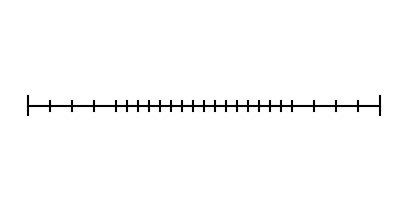

In [3]:
omega = BT.Grid(nh_min)
refCells = nh_min // 2
finepart = list(np.arange(refCells) + int(nh_min // 4))
omega.AddPatch(refRatio, finepart)
degFreed = omega.degFreed
nh_max = omega.nh_max
PT.PlotGrid(omega, label = False)

In [4]:
physics = BT.PhysProps(omega, epsilons, mus, locs, L)
cVec = physics.cVec
cMat = physics.cMat
cs = physics.cs

In [5]:
t = 312341234
sigma, mu = WFT.GaussParams(x_0, x_1)
args = [sigma, mu]
waveInit = WFT.InitCond(omega, physics, WFT.Gauss, args, deriv = False)


YOU ARE RUNNING GAUSS! False



In [6]:
## Calculate the RHS for E,B in Maxwell's equations using 5th-order upwind
def WaveEqRHS(omega, physics, u0, t, orderIn, diff):
    print('You are using WaveEqRHS()!')
    
    degFreed = omega.degFreed
    cs = physics.cVec
    matInd = physics.matInd
    
    c1 = cs[0]
    c2 = cs[-1]
    
    E = u0[:degFreed]
    B = u0[degFreed:]

    refluxOp1, refluxOp2, refluxOp = RefluxOp(omega, physics, orderIn, deriv)

    refluxE = refluxOp @ E
    refluxB = refluxOp @ B
    
    hMat = OT.StepMatrix(omega)
    
    # Fill in ghost cells for left, right domain - need 3 for up5
    if ((diff == 'CD') or (diff == 'C')):
        if (orderIn % 2 == 0):
            order = orderIn
        else:
            order = int(orderIn + 1)
        Ng = int(order / 2)
    else:
        if (orderIn % 2 == 0):
            order = int(orderIn + 1)
        else:
            order = orderIn
        Ng = int((order + 1) / 2)
    
    Eg1, Eg2 = OT.GhostCellsJump(omega, physics, E, Ng, order)
    Bg1, Bg2 = OT.GhostCellsJump(omega, physics, B, Ng, order)

    # Transform to the computational vars w/ eigen xform
    E1 = np.concatenate((E[:matInd], Eg1))  # with ghost cell values at the jump
    B1 = np.concatenate((B[:matInd], Bg1))
    phil1 = 0.5 * (E1 - c1 * B1)  # characteristic variable
    phir1 = 0.5 * (E1 + c1 * B1)
    E2 = np.concatenate((Eg2, E[matInd:]))  # with ghost cell values at the jump
    B2 = np.concatenate((Bg2, B[matInd:]))
    phil2 = 0.5 * (E2 - c2 * B2)
    phir2 = 0.5 * (E2 + c2 * B2)

    # Regular Face stencil from cell-averages
    
    faceOp1L, faceOp2L, faceOpL = OT.FaceOp(omega, order, diff, 'L', Ng)
    faceOp1R, faceOp2R, faceOpR = OT.FaceOp(omega, order, diff, 'R', Ng)
    
    # Face values from upwind (index 1:N for faces left of cell + 1 for mat)
    phil1f = faceOp1L @ np.concatenate((np.full(Ng, phil1[0]), phil1))  # outflow bc's on left
    phir1f = faceOp1R @ np.concatenate((np.zeros(Ng), phir1))  # 0 at leftmost face for inflow boundary conditions
    phil2f = faceOp2L @ np.concatenate((phil2, np.zeros(Ng))).transpose()  # 0 at rightmost face for inflow boundary conditions
    phir2f = faceOp2R @ np.concatenate((phir2, np.full(Ng, phir2[matInd + Ng - 1])))  # outflow bc's on right
    
    
    # Correct values at material interface with jump conditions
    T1 = 2 * c1 / (c1 + c2)
    R1 = (c2 - c1) / (c1 + c2)
    phil1f[matInd] = T1 * phil2f[0] + R1 * phir1f[matInd]
    T2 = 2 * c2 / (c1 + c2)
    R2 = (c1 - c2) / (c1 + c2)
    phir2f[0] = R2 * phil2f[0] + T2 * phir1f[matInd]
    
    # Transform back to E, B on faces
    E1f = phil1f + phir1f
    B1f = (-phil1f + phir1f) / c1
    E2f = phil2f + phir2f
    B2f = (-phil2f + phir2f) / c2
    
    # If AMROverride is set to true, center-difference improves and upwind apparently suffers (at least for low-order. Haven't checked higher orders.) Inverse is also true. (Nevermind. This appears to have only been the case for the polynomial tests?)
    
    faceOp1r, faceOp2r, faceOpr = OT.FaceOp(omega, 1, 'U', 'R', 1, AMROverride = True)
    faceOp1l, faceOp2l, faceOpl = OT.FaceOp(omega, 1, 'U', 'R', 1, otherFace = True, AMROverride = True)
    
    derivOp1 = (faceOp1r - faceOp1l)[1:, :-1]
    derivOp2 = (faceOp2r - faceOp2l)[1:, :-1]

    # Calculate the RHS for E, B
    rhsE = hMat @ np.append(-c1**2*derivOp1 @ B1f, -c2**2*derivOp2 @ B2f) + refluxE
    rhsB = hMat @ np.append(-1*derivOp1 @ E1f, -1* derivOp2 @ E2f) + refluxB
    
    rhs = np.append(rhsE, rhsB)

    return rhs

In [7]:
def AdvectRHS(omega, physics, u0, t, orderIn, diff):
    errorLoc = 'ERROR:\nSolverTools:\nAdvectRHS:\n'
    errorMess = ''
    print('You are using AdvectRHS()!')
    degFreed = omega.degFreed
    cMat = physics.cMat
    cVec = physics.cVec
    locs = physics.locs
    
    c = cVec[0]
    
    hMat = OT.StepMatrix(omega)
    hMatInv = LA.inv(hMat)

    derivOp = OT.SpaceDeriv(omega, orderIn, diff)

    print('derivOp:')
    print(derivOp)
    
    vecLength = np.shape(u0)[0]
    if (vecLength == degFreed):
        rhs = -cMat @ derivOp @ u0
    else:
        if (vecLength == 2 * degFreed):
            E = u0[:degFreed]
            B = u0[degFreed:]

            # Calculate the RHS for E, B
            print('In SolverTools: AdvectRHS(), you need to fix rhsE to work in non-uniform media!')
#             rhsE = -c**2*derivOp @ B
#             rhsB = -1*derivOp @ E
            rhsE = -cMat @ derivOp @ E
            rhsB = LA.inv(cMat) @ rhsE

            rhs = np.append(rhsE, rhsB)
        else:
            errorMess = 'Length of u0 must be either degreed or 2 * degFreed!'
            
    if (errorMess != ''):
        sys.exit(errorLoc + errorMess)

    return rhs


In [8]:
update = AdvectRHS(omega, physics, waveInit, t, orderIn, deriv)

You are using AdvectRHS()!
bounds: [-2.  -1.   0.   0.5  1. ]
bounds: [-2.  -1.   0.   0.5  1. ]
bounds: [-1.  -0.5 -0.   1.   2. ]
derivOp:
[[  8.           5.33333333   0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           2.66666667 -16.        ]
 [-16.           8.           5.33333333   0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           2.66666667]
 [  2.66666667 -16.           8.           5.33333333   0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.           0.  

In [9]:
def RefluxOp(omega, physics, orderIn, deriv):
    degFreed = omega.degFreed
    hs = omega.h
    spots = np.roll(hs, -1) - hs
    cMat = physics.cMat
    
    halfDeg = int(degFreed / 2)
    
    if (all(spots == 0)):
        p = []
        q = []
    #         print('THIS FACE OPERATOR IS UNIFORM!')
    else:
        # Index before fine-coarse interface
        p = np.where(spots > 0)[0][0]
        # Index before coarse-fine interface
        q = np.where(spots < 0)[0][0]
    
    faceOp1, faceOp2, faceOp = OT.FaceOp(omega, orderIn, deriv, 'R', 0, wrapAround = False)
    faceOp = faceOp[1:, :]
    
    # Zero out all of faceOp except this
    inversOpC = faceOp + 0
    inversOpC[[q, p + 1], :] = 0
    fluxOpC = faceOp - inversOpC
    
    inversOpF = faceOp + 0
    inversOpF[[q + 1, p], :] = 0
    preFluxOpF = faceOp - inversOpF
    fluxOpF = np.zeros((degFreed, degFreed), float)
    fluxOpF[q, :] = preFluxOpF[q + 1, :]
    fluxOpF[p + 1, :] = preFluxOpF[p, :]
    
    refluxOp = fluxOpF - fluxOpC
    refluxOp = cMat @ refluxOp
    
    refluxOp1 = refluxOp[:halfDeg, :halfDeg]
    refluxOp2 = refluxOp[halfDeg:, halfDeg:]
    return refluxOp1, refluxOp2, refluxOp

In [10]:
refluxOp1, refluxOp2, refluxOp = OT.RefluxOp(omega, physics, orderIn, deriv)

bounds: [-2.  -1.   0.   0.5  1. ]
bounds: [-1.  -0.5 -0.   1.   2. ]


In [11]:
print('refluxOp:', np.shape(refluxOp))
print(refluxOp)
print('')
print('refluxOp1:', np.shape(refluxOp1))
print(refluxOp1)
print('')
print('refluxOp2:', np.shape(refluxOp2))
print(refluxOp2)
print('')

refluxOp: (24, 24)
[[ 0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                 ]
 [ 0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.                   0.       

In [12]:
# # Left face gets extra row on bottom.
# faceOp1L, faceOp2L, faceOpL = OT.FaceOp(omega, orderIn, deriv, 'L', 0)# Ng)
# # Right face gets extra row on top.
# faceOp1R, faceOp2R, faceOpR = OT.FaceOp(omega, orderIn, deriv, 'R', 0)# Ng)
# derivOp = OT.SpaceDeriv(omega, orderIn, deriv)

refluxOp1, refluxOp2, refluxOp = RefluxOp(omega, orderIn, deriv)

TypeError: RefluxOp() missing 1 required positional argument: 'deriv'

In [ ]:
# print('faceOp1L:')
# print(faceOp1L)
# print('')
# print('faceOp2L:')
# print(faceOp2L)
# print('')
# print('faceOp1R:')
# print(faceOp1R)
# print('')
# print('faceOp2R:')
# print(faceOp2R)
# print('')

In [ ]:
# print('faceOpL:', np.shape(faceOpL))
# print(faceOpL)
# print('')
print('refluxOp:', np.shape(refluxOp))
print(refluxOp)
print('')
print('refluxOp1:', np.shape(refluxOp1))
print(refluxOp1)
print('')
print('refluxOp2:', np.shape(refluxOp2))
print(refluxOp2)
print('')

In [ ]:
print('derivOp:')
print(derivOp)
print('')

In [ ]:
degFreed = omega.degFreed
hs = omega.h
spots = np.roll(hs, -1) - hs
cMat = physics.cMat

halfDeg = int(degFreed / 2)

if (all(spots == 0)):
    p = []
    q = []
#         print('THIS FACE OPERATOR IS UNIFORM!')
else:
    # Index before fine-coarse interface
    p = np.where(spots > 0)[0][0]
    # Index before coarse-fine interface
    q = np.where(spots < 0)[0][0]

print('spots:', len(spots))
print(spots)
print(p)
print(q)

faceOp1, faceOp2, faceOp = OT.FaceOp(omega, orderIn, deriv, 'R', 0, wrapAround = False)
faceOp = faceOp[1:, :]

# Zero out all of faceOp except this
inversOpC = faceOp + 0
inversOpC[[q, p + 1], :] = 0
fluxOpC = faceOp - inversOpC

inversOpF = faceOp + 0
inversOpF[[q + 1, p], :] = 0
preFluxOpF = faceOp - inversOpF
fluxOpF = np.zeros((degFreed, degFreed), float)
fluxOpF[q, :] = preFluxOpF[q + 1, :]
fluxOpF[p + 1, :] = preFluxOpF[p, :]

refluxOp = fluxOpF - fluxOpC
refluxOp = cMat @ refluxOp
print(refluxOp)
print('')

refluxOp1 = refluxOp[:halfDeg, :halfDeg]
refluxOp2 = refluxOp[halfDeg:, halfDeg:]
print(refluxOp1)
print('')
print(refluxOp2)
print('')
